In [3]:
import os
import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq

from datetime import datetime

%matplotlib widget

import matplotlib.pyplot as plt

In [1]:
from pathlib import Path

from matplotlib.colors import LinearSegmentedColormap, Normalize

csv_path = Path("../data/cnc_mill_tool_wear/experiment_01.csv")

df = pd.read_csv(csv_path)

x = df['X1_ActualPosition']
y = df['Y1_ActualPosition']
z = df['Z1_ActualPosition']

idx = np.arange(200, 300)

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(x[idx], y[idx], '.', alpha=0.2)



NameError: name 'pd' is not defined

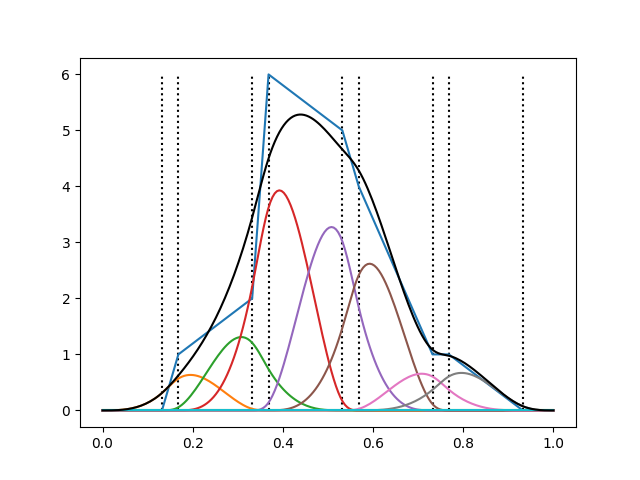

In [79]:

import pandas as pd
import numpy as np
import math 

import random

# cox-de-boor recursion formula that only uses k points
# @param T timestamps of the sampling points t_0 ... t_k
# @param t the timestamp to be interpolated
# @param k grade of the spline
# @returns value of B_i,k
def bSplineBase(T, t, k):

    B = np.zeros((T.size, k))
    # fill in zero matrix and condition for the first column
    for i in range(0, T.size-1):
        # st.write(T[i],T[i+1])
        firstRow = np.zeros(k)
        if T[i] <= t and t < T[i+1]:
            firstRow[0] = 1 # B_i,0(t) = 1 if t_i <= t t_i+1

        # st.write(firstRow)

        B[i,:] = firstRow

    # st.write(T)

    # fill rest
    # for (let j = 1; j < k; j++){
    for j in range(1,k):
        # for (let i = 0; i < k-1; i++){
        for i in range(0, k-1):

            if i+j >= T.size:
                a = 0
            else:
                a = (t - T[i]) / (T[i+j] - T[i]) # first fraction of the formula: (t - t_i) / (t_i+j - t_i)
            # if (!isFinite(a)) a = 0; // check for division par zero
            
            if i+j+1 >= T.size:
                b = 0
            else:
                b = (T[i+j+1] - t) / (T[i+j+1] - T[i+1]) # second fraction: (t_i+j+1 - t) / (t_i+j+1 - t_i+1)
            # if (!isFinite(b)) b = 0; // check for division par zero

            B[i][j] = a*B[i][j-1] + b*B[i+1][j-1] # B_i,j(t) = a*B_i,j-1(t) + b*B_i+1,j-1(t)
        
    # st.write(B)
    # print(B)

    return B[0,k-1]


# naive implementation of the cox-de-boor recursion formula
# @param T timestamps of the sampling points t_0 ... t_i ... t_n
# @param t the timestamp to be interpolated
# @param k grade of the spline
# @returns bernstein polynom base matrix at t
def naiveBSplineBase(T, t, k):

    n = T.size # amount of sampling points
    B = np.zeros((T.size, k))
    # fill in zero matrix and condition for the first column
    # for (let i = 0; i < T.length; i++){
    for i in range(0, n):
        if T[i] <= t and (i == n-1 or t < T[i+1]):
            B[i,0] = 1 # B_i,0(t) = 1 if t_i <= t t_i+1

    # fill rest
    # for (let j = 1; j < k; j++){
    for j in range(1,k):
        # for (let i = 0; i < n-1; i++){
        for i in range(0, n-1):

            if i+j >= T.size:
                a = 0
            else:
                a = (t - T[i]) / (T[i+j] - T[i]) # first fraction of the formula: (t - t_i) / (t_i+j - t_i)
            # if (!isFinite(a)) a = 0; // check for division par zero
            
            if i+j+1 >= T.size:
                b = 0
            else:
                b = (T[i+j+1] - t) / (T[i+j+1] - T[i+1]) # second fraction: (t_i+j+1 - t) / (t_i+j+1 - t_i+1)
            # if (!isFinite(b)) b = 0; // check for division par zero

            B[i,j] = a*B[i,j-1] + b*B[i+1,j-1] # B_i,j(t) = a*B_i,j-1(t) + b*B_i+1,j-1(t)
        
    

    return B


def splineInterpolation(sample, t, k=4):
    v = 0
    for i in range(0,k):
        sample_part = sample[i:i+k+1]
        v = v + bSplineBase(sample_part[:,0], t, k)*sample_part[int(k/2),1]

    return v

def find_index(part, t):
    i = -1
    for j in range(0, part.shape[0]-1):
        if part[j,0] <= t and t < part[j+1,0]:
            i = j

    return i

def spline_interp(part, t_res, k=4):
    # spline = np.array([])
    spline = []

    # i = k
    for t in t_res:

        i = find_index(part, t)

        # st.write(t)
        if i > 0:
            sample = part[i-k+1:i+k+1,:]
            if sample.size > 0:
                v = splineInterpolation(sample, t, k)
                # spline = np.append(spline, [v])
                spline.append([t, v])


    return np.array(spline)

k = 4

n_sample = 11
sample = np.zeros([n_sample, 2])
# sample[0,0] = 0.0
# sample[1,0] = 0.1
# sample[2,0] = 0.2
# sample[3,0] = 0.3
# sample[4,0] = 0.4
# sample[5,0] = 0.5
# sample[6,0] = 0.6
# sample[7,0] = 0.7
# sample[8,0] = 0.8
# sample[9,0] = 0.9
# sample[10,0] = 1.0 
sample[:,0] = np.linspace(0.0, 1.0, n_sample)
# for i in range(1, n_sample-1):
#     sample[i,0] += random.random()*0.1
# sample[:,1] = x[110:110+n_sample]
sample[0,1] = 0
sample[1,1] = 0
sample[2,1] = 1
sample[3,1] = 2
sample[4,1] = 6
sample[5,1] = 5
sample[6,1] = 4
sample[7,1] = 1
sample[8,1] = 1
sample[9,1] = 0
sample[10,1] = 0 
sample[:,1] = sample[:,1]-np.min(sample[:,1])


fig, ax = plt.subplots()
for i in range(1, n_sample-1):
    # sample[i,0] += (random.random()-0.5)*1.0/n_sample*0.4
    sample[i,0] += ((i%2)-0.5)*1.0/n_sample*0.7
    ax.plot([sample[i,0], sample[i,0]], [np.min(sample[:,1]),np.max(sample[:,1])], 'k:')


# v = splineInterpolation(sample, 0.5, k)
# print(v)

ax.plot(sample[:,0], sample[:,1])
# ax.plot([0.5], [v], 'X')

res = 200
t_res = np.linspace(0.0, 1.0, res)
debug_B = np.zeros([res, k])
v = 0
t = 0.5
spline = np.zeros(res)
b_splines = np.zeros([res,n_sample])
for i in range(0,res):
    t_i = t_res[i]
    # sample_part = sample[i:i+k+1]
    # v = v + bSplineBase(sample_part[:,0], t, k)*sample_part[int(k/2),1]
    B = naiveBSplineBase(sample[:,0], t_i, k)

    for j in range(0,n_sample-k//2):
        b_splines[i,j] = B[j,k-1]*sample[j+k//2,1]
        spline[i] = spline[i] + b_splines[i,j]
        
        # ax.plot([t_i], [B[j,k-1]*sample[j+k//2,1]], 'k.')
    # print(B.shape)

for j in range(0,n_sample-k//2):
    ax.plot(t_res, b_splines[:,j])

ax.plot(t_res, spline, 'k')
